Load packages

In [6]:
import re

import matplotlib.pyplot as plt
from numpy import log2
import pandas as pd
import seaborn as sns

Load data

In [54]:
DATA_PATH = "../test_files/chrY_4gb_test.csv"
test_data = pd.read_csv(DATA_PATH)

Compute ticks for histograms

In [3]:
MAX_DIST = 2e6
resolution = int(re.findall(r"_res\d*", DATA_PATH)[0][4:])
box_ticks = [f"{t*int(resolution/1000)}kb" for t in range(1, 1+int(MAX_DIST//resolution))]

Compute expected counts according to different statistics

In [4]:
expected_mean = test_data.groupby("distance").mean()
expected_mean["statistic"] = "mean"
expected_median = test_data.groupby("distance").median()
expected_median["statistic"] = "median"
expected_counts = pd.concat([expected_mean, expected_median]).reset_index()
expected_counts.head()

,distance,count,statistic
0,10000,27.508329,mean
1,20000,15.461396,mean
2,30000,11.763243,mean
3,40000,9.678381,mean
4,50000,8.410366,mean


In [5]:
norm_data = pd.read_csv(DATA_PATH)
norm_data["mean_norm"] = norm_data.groupby("distance")["count"].transform("mean")
norm_data["mean_norm"] = log2(norm_data["count"] / norm_data["mean_norm"])
norm_data["median_norm"] = norm_data.groupby("distance")["count"].transform("median")
norm_data["median_norm"] = log2(norm_data["count"] / norm_data["median_norm"])
print(len(norm_data[norm_data["mean_norm"] > 0]))
print(len(norm_data[norm_data["median_norm"] > 0]))

486017
482374


In [6]:
test_data[test_data["distance"]==100000]

,count,distance
73,3,100000
214,2,100000
299,4,100000
350,2,100000
510,3,100000
...,...,...
1336883,1,100000
1336900,4,100000
1336911,3,100000
1336922,7,100000


<Axes: xlabel='distance', ylabel='count'>

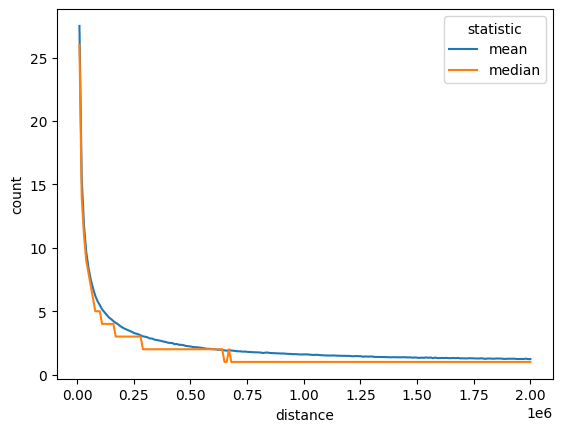

In [7]:
sns.lineplot(expected_counts, x="distance", y="count", hue="statistic")

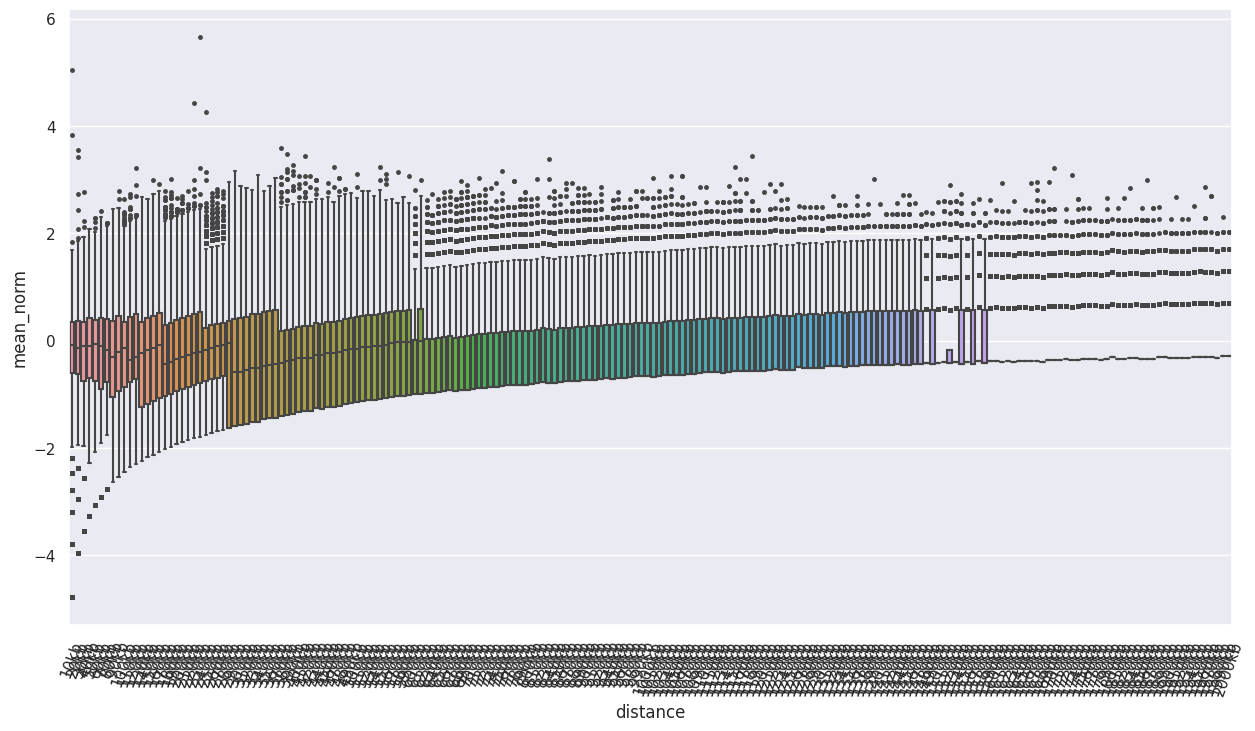

In [24]:
sns.set(rc = {'figure.figsize':(15,8)})
ax = sns.boxplot(data=norm_data, x="distance", y="mean_norm", flierprops={"marker":"."})
_= ax.set_xticklabels(box_ticks, rotation=70)

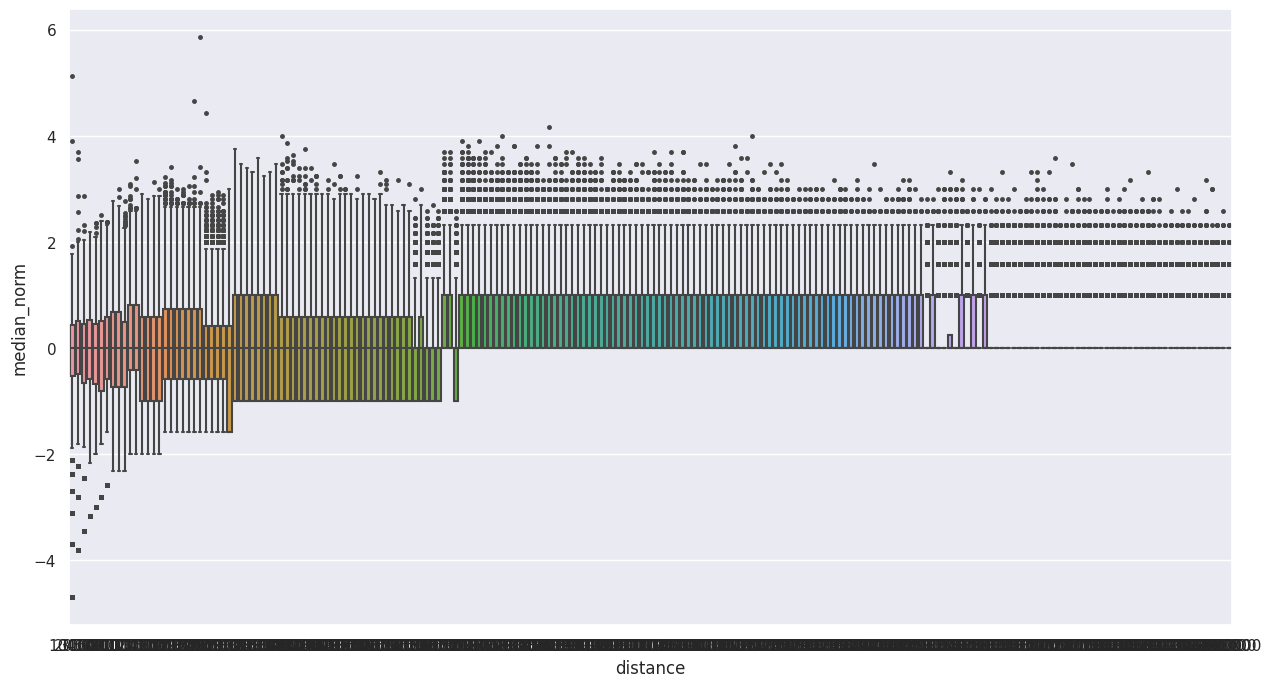

In [25]:
_ = sns.boxplot(data=norm_data, x="distance", y="median_norm", flierprops={"marker":"."})

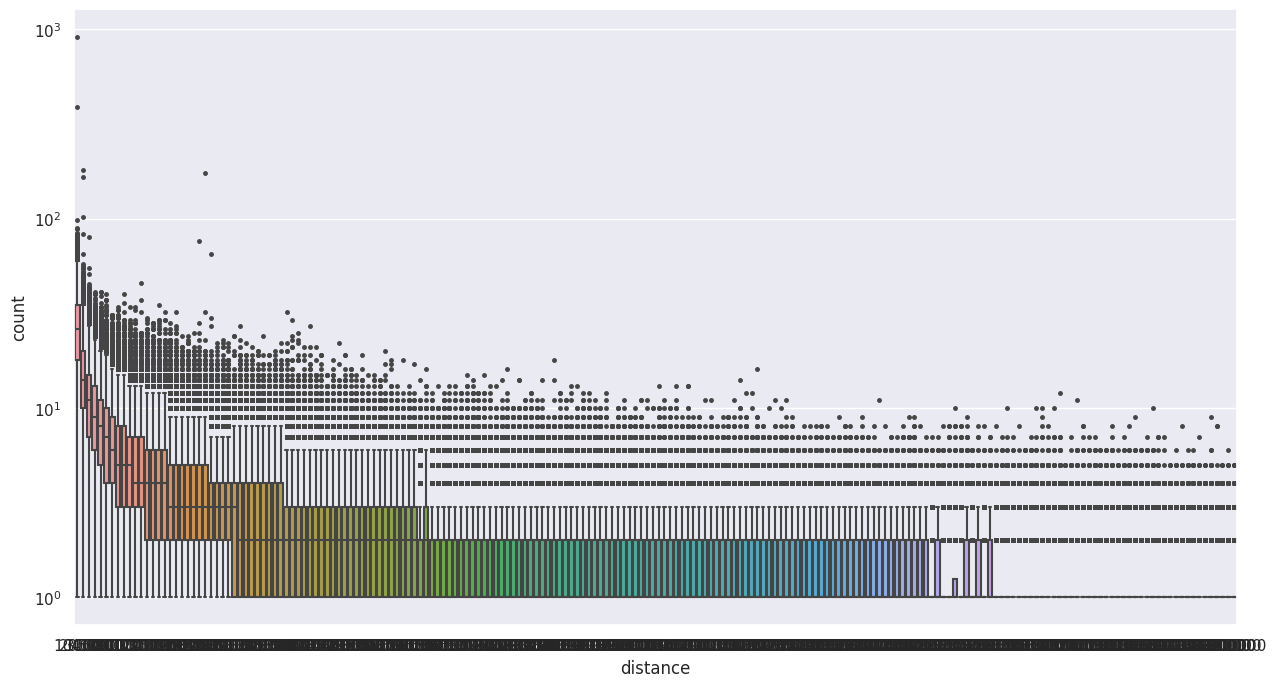

In [33]:
_ = sns.boxplot(data=test_data, x="distance", y="count", flierprops={"marker":"."})
plt.yscale('log')

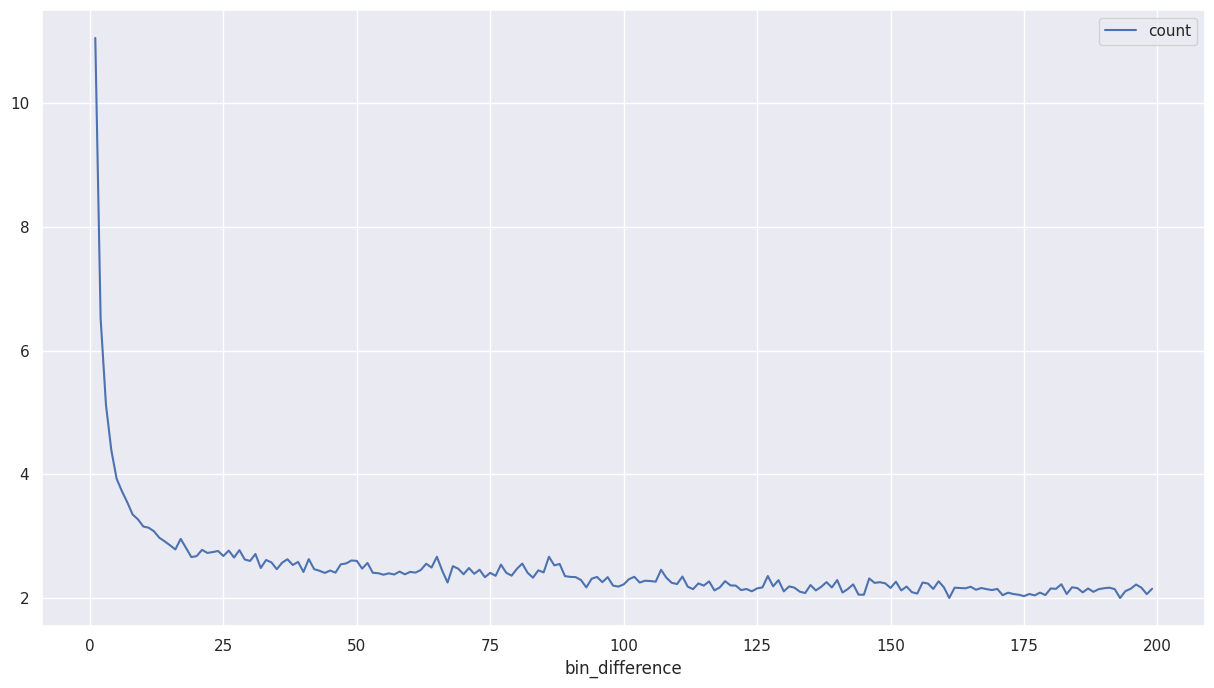

In [74]:
test_data["bin_difference"] = test_data["bin2_id"] - test_data["bin1_id"]
group_counts = test_data.groupby("bin_difference")["count"]
decay_curve = group_counts.agg("mean").to_frame()
decay_curve.reset_index(inplace=True)
decay_curve.plot(x="bin_difference", y="count")
plt.show()

In [56]:
def decay_function(x, a, b, c):
    return a * exp(-b * x) + c

In [58]:
from scipy.optimize import curve_fit
from numpy import exp

param_vals, param_cov = curve_fit(decay_function, decay_curve["bin_difference"], decay_curve["count"])

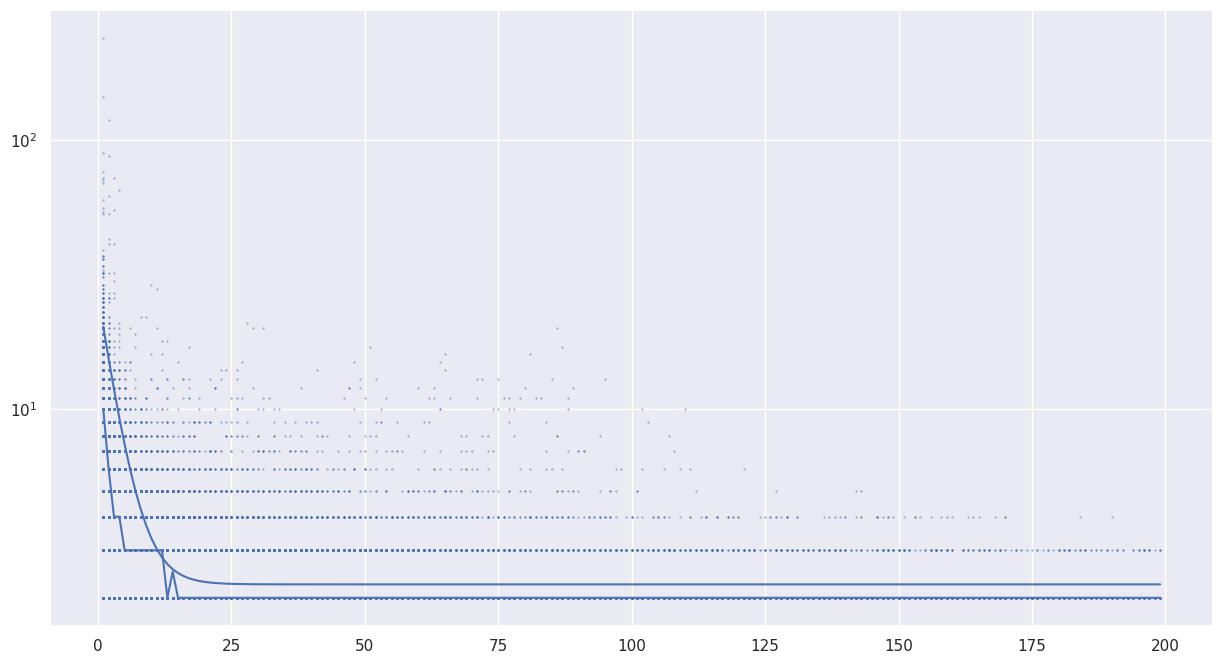

In [59]:
sns.set(rc = {'figure.figsize':(15,8)})
plt.plot(decay_curve["bin_difference"], decay_function(decay_curve["bin_difference"], *popt))
plt.plot(decay_curve["bin_difference"], decay_curve["count"], 'b-', label='data')
plt.scatter(test_data["bin_difference"], test_data["count"], s=0.1)
plt.yscale("log")

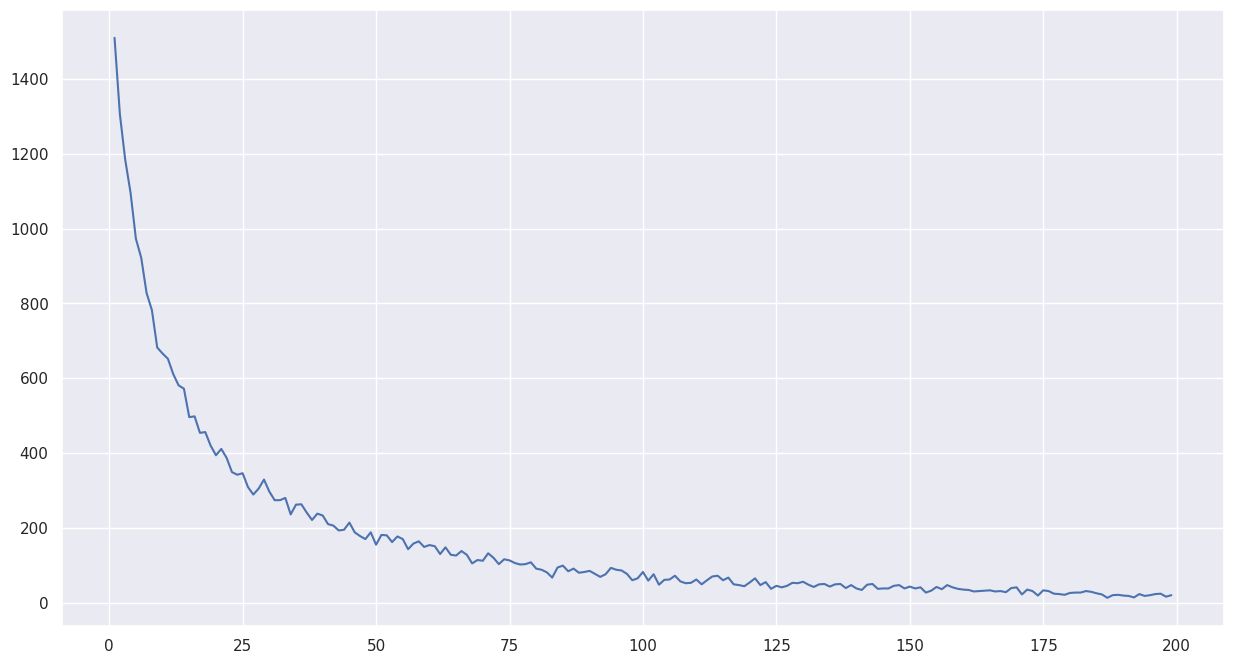

In [73]:
num_per_dist = test_data.groupby("bin_difference")["count"].count()
plt.plot(num_per_dist)